# RDS Homework 2 Problem 3 — SHAP


In [2]:
!pip install shap

In [3]:
from __future__ import print_function

import shap
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.ensemble
import sklearn.metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import tqdm
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import fetch_20newsgroups
from collections import defaultdict
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

# Configs
np.random.seed(1)
shap.initjs()
sns.set_style("whitegrid")

plot_shap=True # NOTE: Turn False to disable shap plots as they can be slow to load

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


## Problem 3

### Part (A)

In [4]:
# Mark the categories of interest
categories = ['alt.atheism', 'soc.religion.christian']

# Fetch the data
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)

# Set outcome class names
class_names = ['atheism', 'christian']
dir(newsgroups_train)

['DESCR', 'data', 'filenames', 'target', 'target_names']

In [5]:
# Initialize & fit tf-idf vectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=10000
)

X_train_tfidf = vectorizer.fit_transform(newsgroups_train.data)

X_test_tfidf = vectorizer.transform(newsgroups_test.data)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(1079, 10000)
(717, 10000)


In [14]:
# Train & fit the classifier
from sklearn.metrics import accuracy_score

clf = SGDClassifier(loss="log_loss", random_state=42)
clf.fit(X_train_tfidf, newsgroups_train.target)

y_pred = clf.predict(X_test_tfidf)

### Part (B)

In [15]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(newsgroups_test.target, y_pred)
print("Confusion Matrix:")
print(conf_mat)


Confusion Matrix:
[[275  44]
 [  4 394]]


#### Explainer

In [16]:
# Initialize the explainer and apply to test data
feature_names = vectorizer.get_feature_names_out()

explainer = shap.Explainer(clf, X_train_tfidf, feature_names=feature_names)


In [17]:
# Select 5 documents in the test set for explanation

import numpy as np

correct_idx = np.where(y_pred == newsgroups_test.target)[0]
wrong_idx = np.where(y_pred != newsgroups_test.target)[0]

print("Number correct:", len(correct_idx))
print("Number wrong:", len(wrong_idx))

selected_idx = list(correct_idx[:3]) + list(wrong_idx[:2])
print("Selected indices:", selected_idx)

Number correct: 669
Number wrong: 48
Selected indices: [np.int64(1), np.int64(2), np.int64(3), np.int64(0), np.int64(25)]


Document 1 (test index = 1)
True label: christian
Predicted label: christian

Document preview:
From: tdarcos@access.digex.net (Paul Robinson)
Subject: Homosexuality is Immoral (non-religious argument)
Organization: Tansin A. Darcos & Company, Silver Spring, MD USA
Lines: 43

[This was crossposted to a zillion groups.  I don't intend to
carry an entire discussion crossposted from alt.sex, particularly
one whose motivation seems to be having a fun argument.  However
I thought readers might be interested to know about the
discussion there.  --clh]

I intend to endeavor to make the argument that homosexuality is an
immoral practice or lifestyle or whatever you call it.  I intend to
show that there is a basis for a rational declaration of this
statement.  I intend to also show that such a declaration can be 
made without there being a religious justification for morality,
in fact to show that such a standard can be made if one is an atheist.

Anyone who wants to join in on the fun in takin

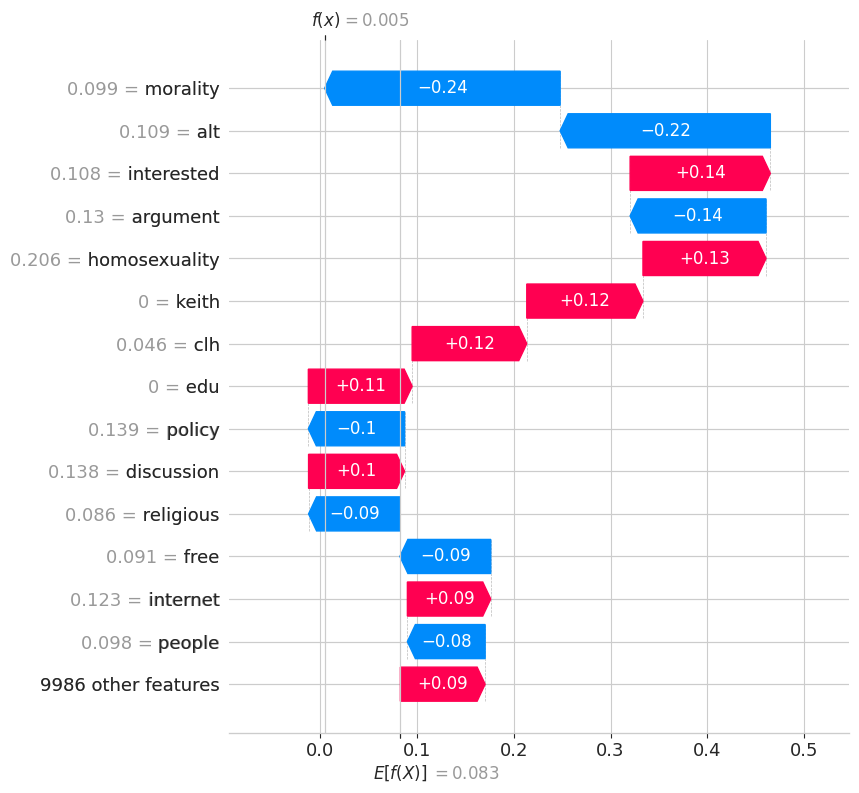

Document 2 (test index = 2)
True label: atheism
Predicted label: atheism

Document preview:
From: madhaus@netcom.com (Maddi Hausmann)
Subject: Re: Amusing atheists and agnostics
Organization: Society for Putting Things on Top of Other Things
Lines: 26

timmbake@mcl.ucsb.edu ("Half" Bake Timmons) writes: >
Maddi: >>

>>Whirr click whirr...Frank O'Dwyer might also be contained
>>in that shell...pop stack to determine...whirr...click..whirr
>
>>"Killfile" Keith Allen Schneider = Frank "Closet Theist" O'Dwyer = ...

>= Maddi "The Mad Sound-O-Geek" Hausmann

No, no, no!  I've already been named by "Killfile" Keith.
My nickname is Maddi "Never a Useful Post" Hausmann, and
don't you DARE forget it, "Half".

>-- "...there's nothing higher, stronger, more wholesome and more useful in life
>than some good memory..." -- Alyosha in Brothers Karamazov (Dostoevsky)

You really should quote Ivan Karamazov instead(on a.a), as he was
the atheist.

-- 
Maddi Hausmann                       madhaus@netcom

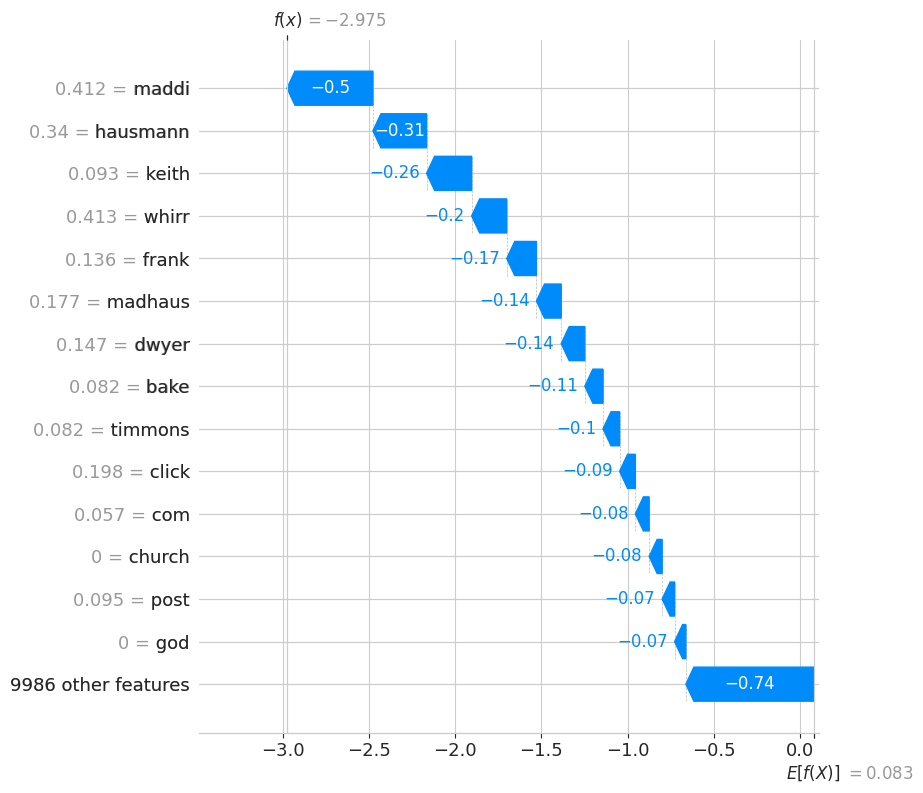

Document 3 (test index = 3)
True label: christian
Predicted label: christian

Document preview:
From: mls@panix.com (Michael Siemon)
Subject: Re: homosexual issues in Christianity
Organization: Panix Public Access Internet & Unix, NYC
Lines: 164

In article <May.11.02.36.34.1993.28074@athos.rutgers.edu> mserv@mozart.cc.iup.edu (someone named Mark) writes:

>mls@panix.com (Michael Siemon) writes:
 
>>Homosexual Christians have indeed "checked out" these verses.  Some of
>>them are used against us only through incredibly perverse interpretations.
>>Others simply do not address the issues.

>I can see that some of the above verses do not clearly address the issues, 

There are exactly ZERO verses that "clearly" address the issues.

>however, a couple of them seem as though they do not require "incredibly 
>perverse interpretations" in order to be seen as condemning homosexuality.

The kind of interpretation I see as "incredibly perverse" is that applied
to the story of Sodom as if it were

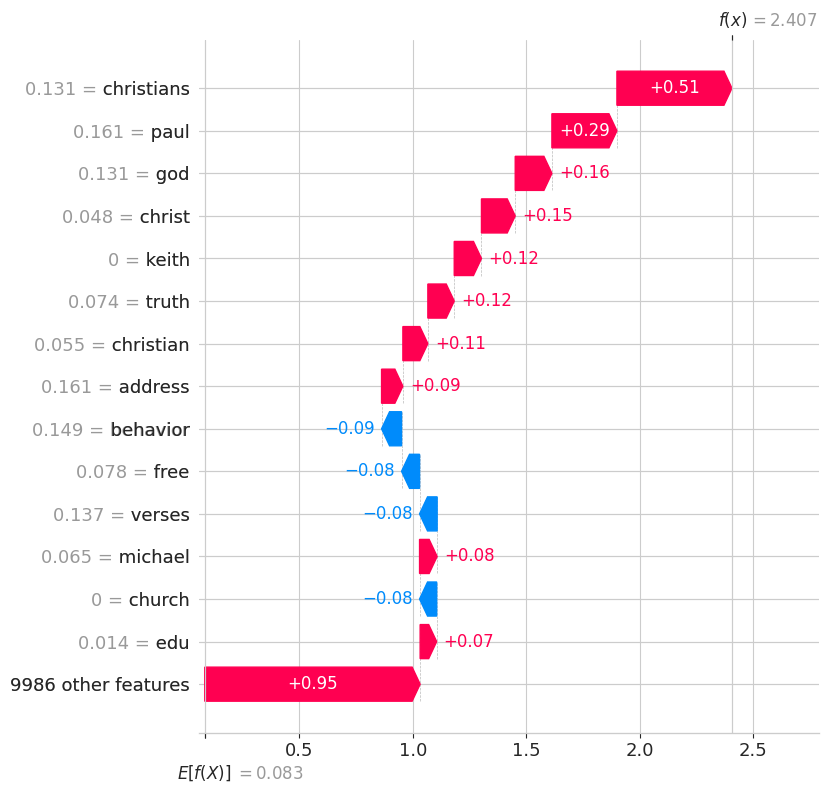

Document 4 (test index = 0)
True label: christian
Predicted label: atheism

Document preview:
From: crackle!dabbott@munnari.oz.au (NAME)
Subject: "Why I am not Bertrand Russell" (2nd request)
Reply-To: dabbott@augean.eleceng.adelaide.edu.au (Derek Abbott)
Organization: Electrical & Electronic Eng., University of Adelaide
Lines: 4

Could the guy who wrote the article "Why I am not Bertrand Russell"
resend me a copy?

Sorry, I accidently deleted my copy and forgot your name.




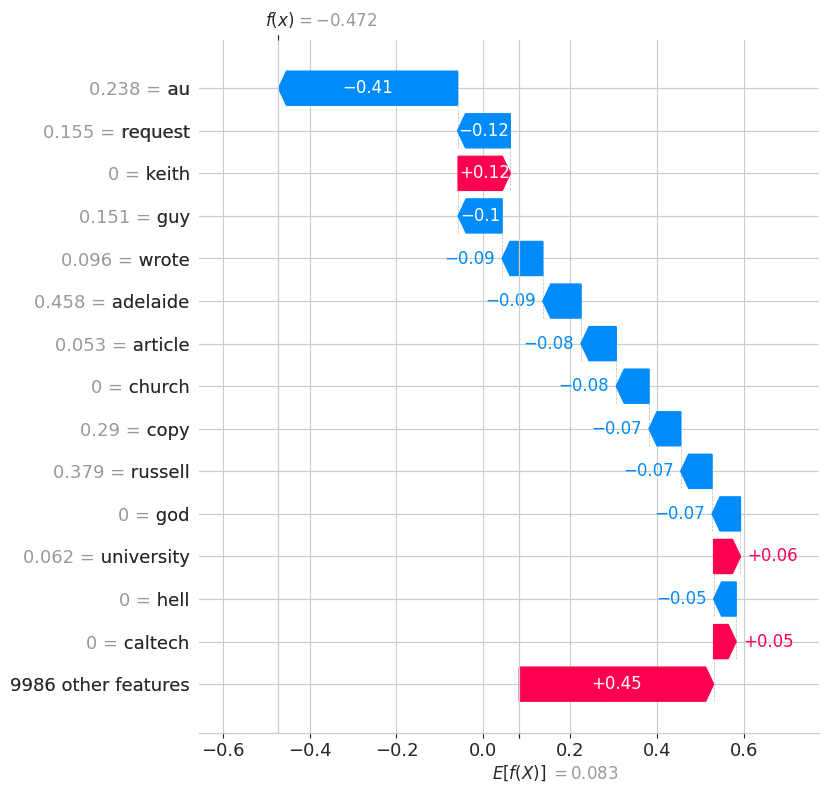

Document 5 (test index = 25)
True label: atheism
Predicted label: christian

Document preview:
From: aaron@minster.york.ac.uk
Subject: Re: Gulf War / Selling Arms
Distribution: world
Organization: Department of Computer Science, University of York, England
Lines: 14

Mark McCullough (mccullou@snake10.cs.wisc.edu) wrote:
: I heard about the arms sale to Saudi Arabia.  Now, how is it such a grave
: mistake to sell Saudi Arabia weapons?  Or are you claiming that we shouldn't
: sell any weapons to other countries?  Straightforward answer please.

Saudi Arabia is an oppressive regime that has been recently interfering
in the politcs of newly renunified Yemen, including assasinations and 
border incursions. It is entirely possible that they will soon invade.
Unluckily for Yemen it is not popular in the West as they managed to put
aside political differences during reunification and thus the West has
effectively lost one half (North?) as a client state.

		Aaron Turner
 




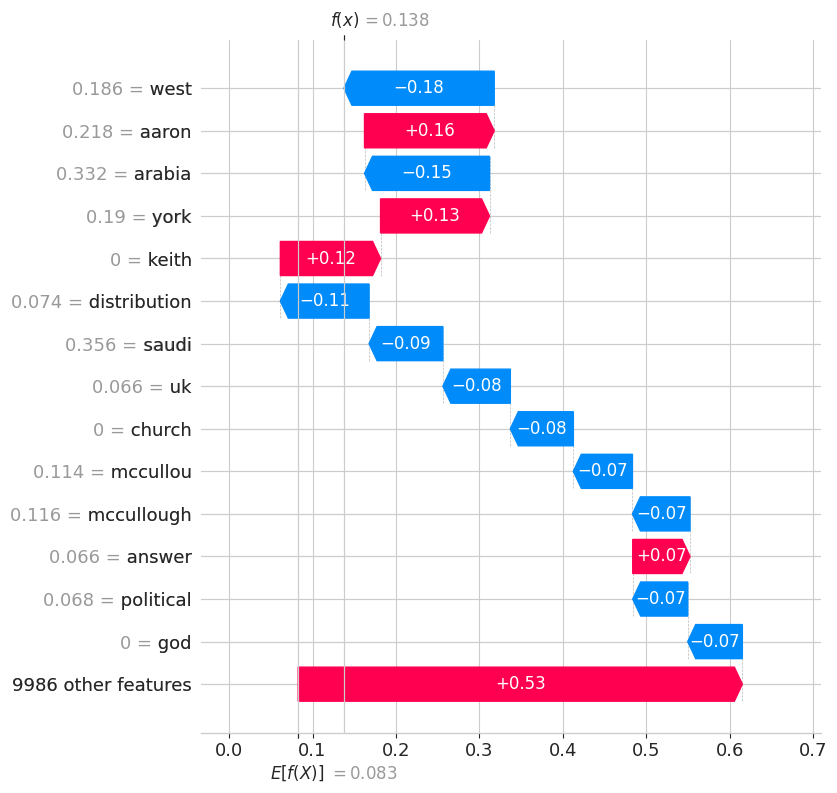

In [18]:
# Visually explain 5 documents selected from the test set

shap_values = explainer(X_test_tfidf[selected_idx])

for i, idx in enumerate(selected_idx):
    print("=" * 80)
    print(f"Document {i+1} (test index = {idx})")
    print("True label:", class_names[newsgroups_test.target[idx]])
    print("Predicted label:", class_names[y_pred[idx]])
    print()
    print("Document preview:")
    print(newsgroups_test.data[idx])
    print()

    shap.plots.waterfall(shap_values[i], max_display=15)

### Part (C)


#### Part (i)

In [19]:
# Compute the accuracy of the classifier and the number of misclassified documents

acc = accuracy_score(newsgroups_test.target, y_pred)
print("Accuracy:", acc)

num_misclassified = np.sum(y_pred != newsgroups_test.target)
print("Number of misclassified documents:", num_misclassified)

Accuracy: 0.9330543933054394
Number of misclassified documents: 48


#### Part (ii)

In [23]:
# Calculate conf_i for all misclassified documents
import pandas as pd
mis_idx = np.where(y_pred != newsgroups_test.target)[0]

y_proba = clf.predict_proba(X_test_tfidf)

conf_all = np.abs(y_proba[:, 1] - y_proba[:, 0])

mis_conf = conf_all[mis_idx]

mis_df = pd.DataFrame({
    "doc_id": mis_idx,
    "true_label": newsgroups_test.target[mis_idx],
    "pred_label": y_pred[mis_idx],
    "conf_i": mis_conf
}).sort_values("conf_i", ascending=False)

print(mis_df.head(10))

    doc_id  true_label  pred_label    conf_i
36     610           0           1  0.895614
3       54           1           0  0.887215
38     623           0           1  0.797039
4       94           0           1  0.737376
37     620           0           1  0.732290
39     641           0           1  0.598403
27     461           0           1  0.569996
41     668           0           1  0.568972
45     685           1           0  0.562312
44     683           0           1  0.471766


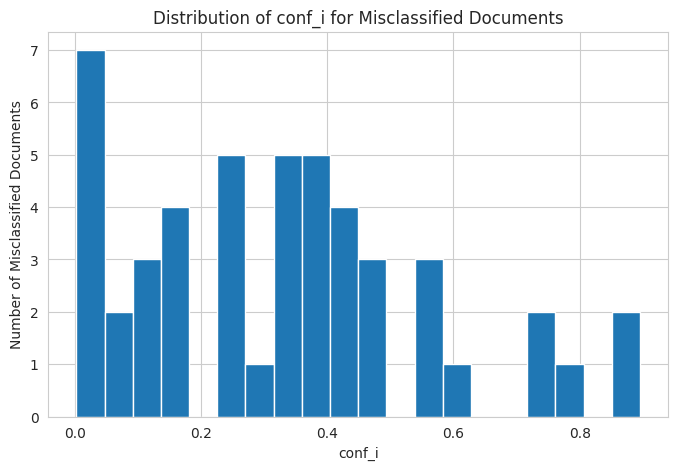

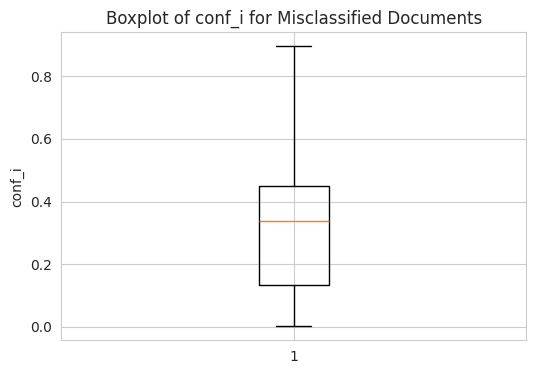

In [24]:
# Plot conf_i

plt.figure(figsize=(8, 5))
plt.hist(mis_df["conf_i"], bins=20)
plt.title("Distribution of conf_i for Misclassified Documents")
plt.xlabel("conf_i")
plt.ylabel("Number of Misclassified Documents")
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot(mis_df["conf_i"], vert=True)
plt.title("Boxplot of conf_i for Misclassified Documents")
plt.ylabel("conf_i")
plt.show()

#### Part (iii)

In [26]:
# Identify tokens (word_j) that contributed to the misclassification of documents
from collections import defaultdict

X_mis = X_test_tfidf[mis_idx]
shap_values = explainer(X_mis)

word_doc_count = defaultdict(int)   # count_j
word_total_weight = defaultdict(float)  # weight_j

In [30]:
# Compute the number of documents (count_j) these words helped to misclassify

for local_i, global_i in enumerate(mis_idx):
    pred_class = y_pred[global_i]

    sv = shap_values[local_i].values

    present_features = X_mis[local_i].indices

    words_in_this_doc = set()

    for j in present_features:
        word = feature_names[j]
        val = sv[j]

        contributes_to_wrong_class = (
            (pred_class == 1 and val > 0) or
            (pred_class == 0 and val < 0)
        )

        if contributes_to_wrong_class:
            words_in_this_doc.add(word)

    for word in words_in_this_doc:
        word_doc_count[word] += 1
print(word_doc_count)

defaultdict(<class 'int'>, {'electronic': 2, 'accidently': 2, 'request': 2, 'forgot': 2, 'bertrand': 2, 'electrical': 2, 'wrote': 4, 'deleted': 2, 'russell': 2, 'guy': 2, 'adelaide': 2, '2nd': 2, 'sorry': 2, 'article': 12, 'copy': 2, 'au': 2, '14': 8, 'aside': 4, 'war': 10, 'answer': 14, 'shouldn': 2, 'arms': 2, 'aaron': 4, 'newly': 2, 'university': 40, 'half': 8, 'edu': 36, 'grave': 2, 'york': 8, 'mark': 14, 'heard': 8, 'sale': 2, 'department': 22, 'subject': 30, 'world': 24, 'ac': 10, 'entirely': 2, 'north': 4, 'differences': 2, 'claiming': 2, 'weapons': 4, 'including': 10, 'lost': 2, 'organization': 46, 'popular': 6, 'lines': 34, '19': 8, 'letters': 4, 'temple': 8, 'indiana': 4, 'time': 24, 'usa': 8, 'happen': 6, 'followed': 12, 'needs': 6, 'pa': 2, 'moved': 2, 'believe': 40, '10': 8, 'year': 8, 'start': 16, 'period': 8, 'dept': 14, 'johnson': 4, 'broken': 2, 'know': 26, 'skeptical': 10, 'appeared': 6, 'great': 24, 'death': 22, 'strife': 2, 'sod': 2, 'say': 6, 'seeing': 2, 'lous': 2

In [31]:
# Compute the sum of absolute SHAP values (weight_j) for each word_j

for local_i, global_i in enumerate(mis_idx):
    pred_class = y_pred[global_i]
    sv = shap_values[local_i].values
    present_features = X_mis[local_i].indices

    for j in present_features:
        word = feature_names[j]
        val = sv[j]

        contributes_to_wrong_class = (
            (pred_class == 1 and val > 0) or
            (pred_class == 0 and val < 0)
        )

        if contributes_to_wrong_class:
            word_total_weight[word] += abs(val)

print(word_total_weight)

defaultdict(<class 'float'>, {'2nd': np.float64(0.005696574301225347), 'accidently': np.float64(0.03231436985673635), 'adelaide': np.float64(0.17610261855806897), 'article': np.float64(0.33388225430447893), 'au': np.float64(0.8243194719643023), 'bertrand': np.float64(0.08420311091563994), 'copy': np.float64(0.14582031925306757), 'deleted': np.float64(0.10030153050331365), 'electrical': np.float64(0.03520592271078414), 'electronic': np.float64(0.04870066323467048), 'forgot': np.float64(0.004110753430584413), 'guy': np.float64(0.20247279799616438), 'request': np.float64(0.24298702140936035), 'russell': np.float64(0.1442893057213481), 'sorry': np.float64(0.09103460618988513), 'wrote': np.float64(0.3060857181535701), '14': np.float64(0.34289713231700564), 'aaron': np.float64(0.5815332309101136), 'ac': np.float64(0.05056285456033108), 'answer': np.float64(0.694670913616883), 'arms': np.float64(0.022935912830396647), 'aside': np.float64(0.1667542192366292), 'claiming': np.float64(0.041821148

In [32]:
word_stats = pd.DataFrame({
    "word_j": list(word_doc_count.keys()),
    "count_j": [word_doc_count[w] for w in word_doc_count.keys()],
    "weight_j": [word_total_weight[w] for w in word_doc_count.keys()]
})

word_stats = word_stats.sort_values(["count_j", "weight_j"], ascending=False)
word_stats.head(20)

,word_j,count_j,weight_j
293,christian,50,7.415142
43,organization,46,0.304458
143,god,40,6.611450
24,university,40,1.474222
57,believe,40,1.463570
26,edu,36,1.333066
278,just,36,0.144432
45,lines,34,0.158082
310,jesus,32,4.837706
126,good,30,0.366740


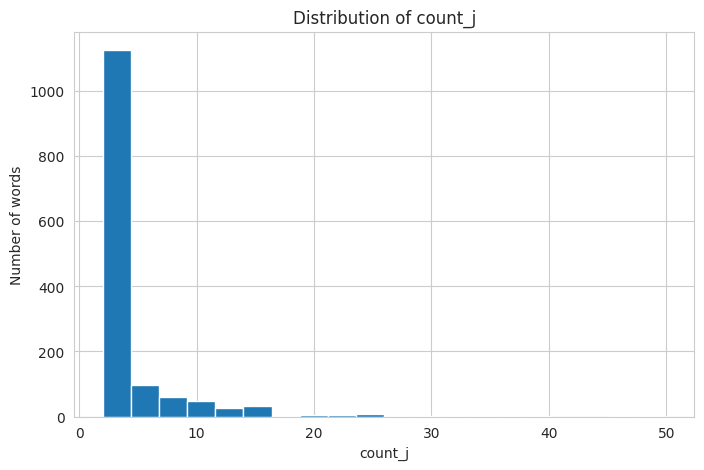

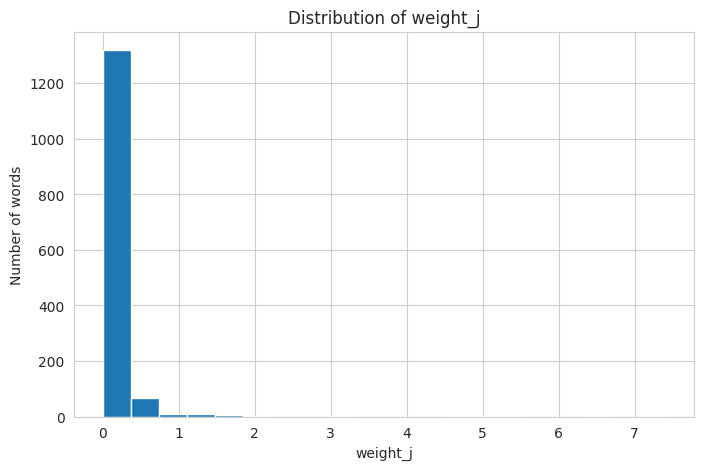

In [33]:
# Plot the distribution of count_j and weight_j

plt.figure(figsize=(8, 5))
plt.hist(word_stats["count_j"], bins=20)
plt.title("Distribution of count_j")
plt.xlabel("count_j")
plt.ylabel("Number of words")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(word_stats["weight_j"], bins=20)
plt.title("Distribution of weight_j")
plt.xlabel("weight_j")
plt.ylabel("Number of words")
plt.show()


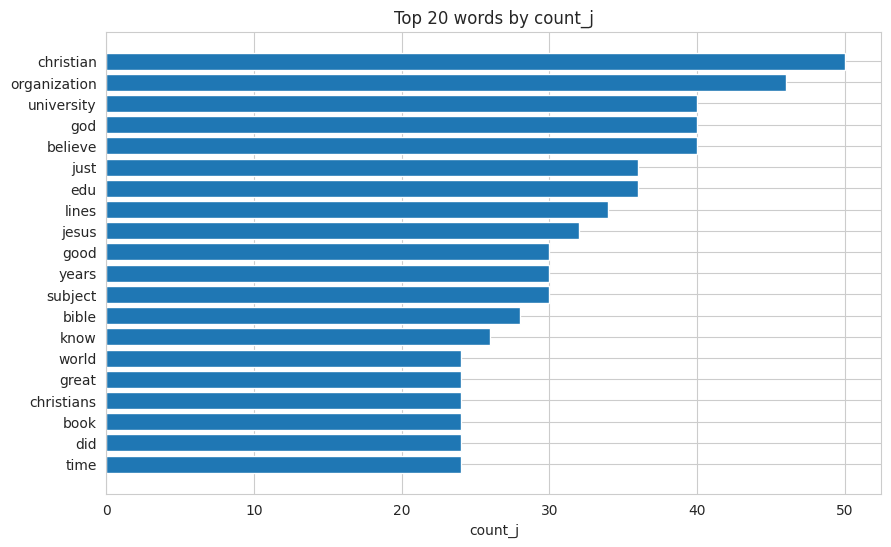

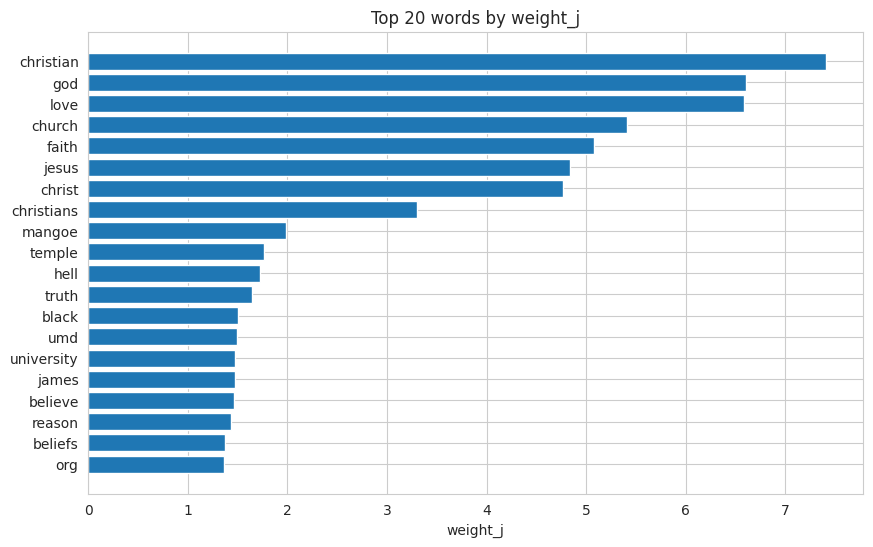

In [34]:
top_count = word_stats.sort_values("count_j", ascending=False).head(20)
top_weight = word_stats.sort_values("weight_j", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_count["word_j"][::-1], top_count["count_j"][::-1])
plt.title("Top 20 words by count_j")
plt.xlabel("count_j")
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(top_weight["word_j"][::-1], top_weight["weight_j"][::-1])
plt.title("Top 20 words by weight_j")
plt.xlabel("weight_j")
plt.show()

### Part (D)

In [35]:
# Implement a strategy for feature selection

k = 20
bad_words = word_stats.sort_values("weight_j", ascending=False).head(k)["word_j"].tolist()

print("Number of removed words:", len(bad_words))
print("Some removed words:", bad_words[:20])

original_vocab = vectorizer.get_feature_names_out()
filtered_vocab = [w for w in original_vocab if w not in bad_words]

print("Original vocab size:", len(original_vocab))
print("Filtered vocab size:", len(filtered_vocab))

vectorizer_fs = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    vocabulary=filtered_vocab
)

X_train_fs = vectorizer_fs.fit_transform(newsgroups_train.data)
X_test_fs = vectorizer_fs.transform(newsgroups_test.data)

clf_fs = SGDClassifier(loss="log_loss", random_state=42)
clf_fs.fit(X_train_fs, newsgroups_train.target)

y_pred_before = clf.predict(X_test_tfidf)
y_pred_after = clf_fs.predict(X_test_fs)

acc_before = accuracy_score(newsgroups_test.target, y_pred_before)
acc_after = accuracy_score(newsgroups_test.target, y_pred_after)

print("Accuracy before feature selection:", acc_before)
print("Accuracy after feature selection:", acc_after)
print("Accuracy improvement:", acc_after - acc_before)

Number of removed words: 20
Some removed words: ['christian', 'god', 'love', 'church', 'faith', 'jesus', 'christ', 'christians', 'mangoe', 'temple', 'hell', 'truth', 'black', 'umd', 'university', 'james', 'believe', 'reason', 'beliefs', 'org']
Original vocab size: 10000
Filtered vocab size: 9980
Accuracy before feature selection: 0.9330543933054394
Accuracy after feature selection: 0.9470013947001394
Accuracy improvement: 0.013947001394700065


In [36]:
# Identify at least one example that was misclassified before feature selection and that is classified correctly after feature selection

y_true = newsgroups_test.target

corrected_idx = np.where(
    (y_pred_before != y_true) & (y_pred_after == y_true)
)[0]

print("Number of corrected examples:", len(corrected_idx))

if len(corrected_idx) > 0:
    ex_idx = corrected_idx[0]

    print("Example index:", ex_idx)
    print("True label:", class_names[y_true[ex_idx]])
    print("Prediction BEFORE:", class_names[y_pred_before[ex_idx]])
    print("Prediction AFTER:", class_names[y_pred_after[ex_idx]])

    print("\n--- Document ---\n")
    print(newsgroups_test.data[ex_idx][:800])
else:
    print("No such example found")

Number of corrected examples: 15
Example index: 123
True label: atheism
Prediction BEFORE: christian
Prediction AFTER: atheism

--- Document ---

From: kempmp@phoenix.oulu.fi (Petri Pihko)
Subject: Re: Christian Morality is
Organization: University of Oulu, Finland
X-Newsreader: TIN [version 1.1 PL6]
Lines: 79

Dan Schaertel,,, (dps@nasa.kodak.com) wrote:

Since this is alt.atheism, I hope you don't mind if we strongly disagree...

: The fact is God could cause you to believe anything He wants you to. 
: But think about it for a minute.  Would you rather have someone love
: you because you made them love you, or because they wanted to
: love you.     The responsibility is on you to love God and take a step toward
: Him.  He promises to be there for you, but you have to look for yourself.

Indeed, "knock and it shall be opened to you". Dan, why didn't this work?
I firmly believed in god for 15 years, but I eventually realised I was
o
